# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## Identificação

| Nome completo | RM |
|---|---|
| Felipe Macedo | 570990 |

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [27]:
import json
import urllib.parse
import urllib.request
import csv

### Bibliotecas para análise e aprendizado de máquina

As células acima (fornecidas no enunciado) usam apenas bibliotecas padrão do Python para consultar as APIs. Abaixo estão os imports adicionados para a análise, os gráficos e os modelos das duas tarefas.

In [28]:
# Manipulação e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão dos dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.dummy import DummyClassifier

# Classificadores (Tarefa 1)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Regressores (Tarefa 2)
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

SEMENTE = 42  # semente fixa: mesmos resultados a cada execução
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [29]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [30]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [31]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [32]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [33]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## Resolução — Tarefa 1 (classificação da fonte)

### 1.1 Carregamento e análise exploratória

In [34]:
df_cls = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")

print("Linhas e colunas:", df_cls.shape)
print("\nTipos das colunas:")
print(df_cls.dtypes)
print("\nValores ausentes por coluna:")
print(df_cls.isnull().sum())
display(df_cls.head())
display(df_cls.describe())

Linhas e colunas: (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64


,potencia_kw,latitude,longitude,fonte
0,20.4800,-10.4428,-64.1519,Solar
1,"5,000.0000",-6.0039,-40.2747,Solar
2,12.2600,-23.5578,-46.7340,Solar
3,3.0000,-23.5589,-46.7350,Solar
4,1.7000,-23.4938,-46.8450,Solar


,potencia_kw,latitude,longitude
count,"3,876.0000","3,876.0000","3,876.0000"
mean,"42,014.6815",-12.6940,-46.1583
std,"301,636.5878",9.5005,8.3575
min,0.1600,-33.7228,-69.9414
25%,440.0000,-21.1421,-52.5618
50%,"12,680.0000",-10.4695,-47.3937
75%,"30,000.0000",-4.1278,-41.2800
max,"11,233,100.0000",3.8314,0.0000


**Checagem de qualidade.** A tabela acima mostra `longitude` com máximo 0,0. Nenhum empreendimento brasileiro fica nessa longitude: o ponto (0, 0) fica no Oceano Atlântico, perto da costa da África. Essas linhas têm a coordenada **não preenchida** no cadastro, registrada como zero. Como elas ensinariam aos modelos uma "localização" falsa, são removidas antes da análise. Também verificamos linhas repetidas.

In [35]:
sem_coordenada = (df_cls["latitude"] == 0) & (df_cls["longitude"] == 0)
print("Linhas com coordenada (0, 0):", sem_coordenada.sum())
print(df_cls.loc[sem_coordenada, "fonte"].value_counts().to_string(), "\n")

df_cls = df_cls.loc[~sem_coordenada].reset_index(drop=True)
print("Linhas após a limpeza:", len(df_cls))
print("Linhas exatamente repetidas (mantidas; podem ser unidades distintas de um mesmo complexo):",
      df_cls.duplicated().sum())

Linhas com coordenada (0, 0): 47
fonte
Eólica        24
Hidráulica    23 

Linhas após a limpeza: 3829
Linhas exatamente repetidas (mantidas; podem ser unidades distintas de um mesmo complexo): 8


In [36]:
# Distribuição das classes (quantidade e proporção)
contagem = df_cls["fonte"].value_counts()
proporcao = df_cls["fonte"].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({"registros": contagem, "% do total": proporcao}))

# Estatísticas das entradas por classe
display(df_cls.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].median()
        .rename(columns=lambda c: f"mediana_{c}"))

,registros,% do total
fonte,,
Hidráulica,1453,37.9000
Solar,1200,31.3000
Eólica,1176,30.7000


,mediana_potencia_kw,mediana_latitude,mediana_longitude
fonte,,,
Eólica,"29,400.0000",-8.0368,-40.7269
Hidráulica,"4,000.0000",-22.1487,-50.5415
Solar,1.0000,-2.0555,-52.4409


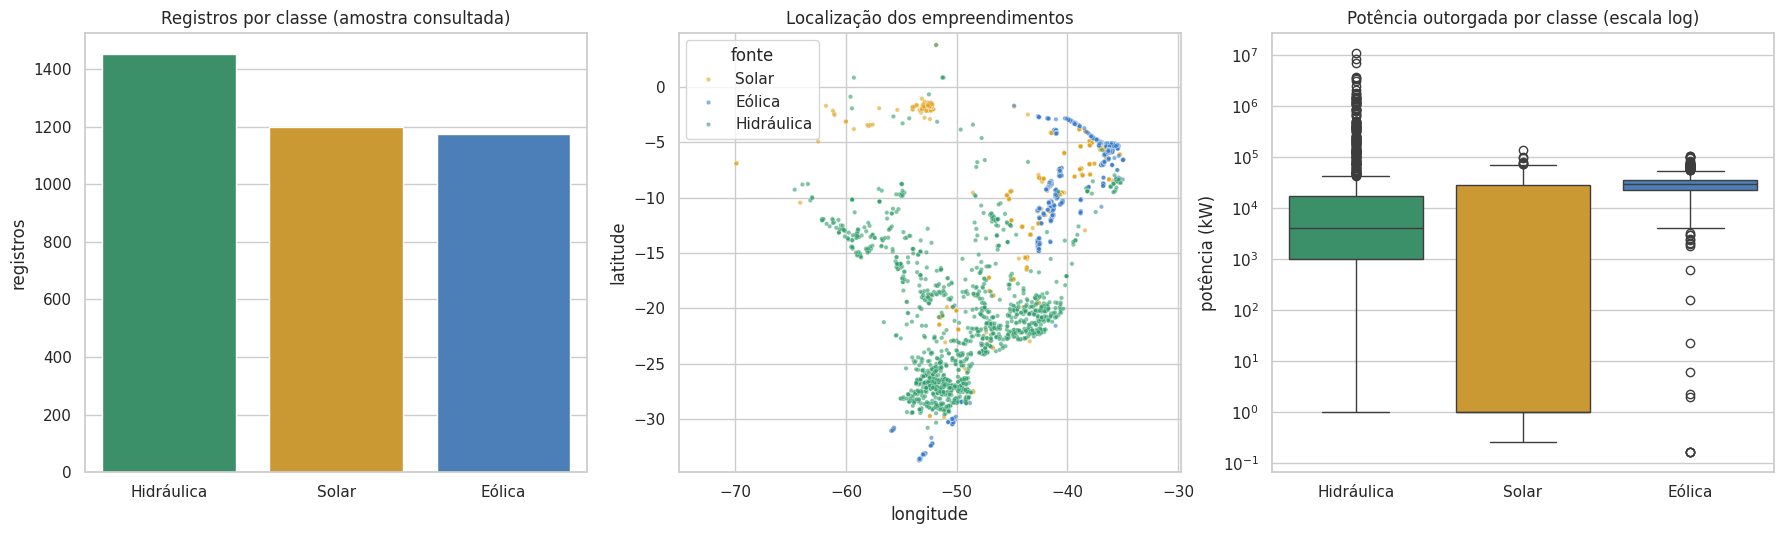

In [37]:
CORES = {"Solar": "#E3A21A", "Eólica": "#3A7DC9", "Hidráulica": "#2E9E6A"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Quantidade por classe
sns.countplot(data=df_cls, x="fonte", hue="fonte", palette=CORES, legend=False, ax=axes[0],
              order=contagem.index)
axes[0].set_title("Registros por classe (amostra consultada)")
axes[0].set_xlabel(""); axes[0].set_ylabel("registros")

# (b) Localização: longitude x latitude funciona como um "mapa" do Brasil
sns.scatterplot(data=df_cls, x="longitude", y="latitude", hue="fonte", palette=CORES,
                s=10, alpha=0.6, ax=axes[1])
axes[1].set_title("Localização dos empreendimentos")
axes[1].set_aspect("equal", adjustable="datalim")

# (c) Potência: distribuição muito assimétrica, por isso escala logarítmica
sns.boxplot(data=df_cls, x="fonte", y="potencia_kw", hue="fonte", palette=CORES, legend=False,
            ax=axes[2], order=contagem.index)
axes[2].set_yscale("log")
axes[2].set_title("Potência outorgada por classe (escala log)")
axes[2].set_xlabel(""); axes[2].set_ylabel("potência (kW)")

plt.tight_layout()
plt.show()

### Registro da análise exploratória — Tarefa 1

- **Tamanho e qualidade:** o CSV tem 3.876 linhas, 4 colunas e nenhum valor ausente. Encontramos, porém, **47 linhas com coordenada (0, 0)** (24 eólicas e 23 hidráulicas). Essas coordenadas não foram preenchidas no cadastro e as linhas foram removidas. Restaram **3.829 empreendimentos**.
- **Distribuição das classes:** Hidráulica tem 1.453 registros (37,9%), Solar 1.200 (31,3%) e Eólica 1.176 (30,7%). Hidráulica é maior porque reúne três siglas (UHE, PCH e CGH). Solar e Eólica atingiram o limite de 1.200 registros por consulta do notebook. O desequilíbrio é moderado. Essas proporções refletem **apenas a forma da consulta** e não representam a participação das fontes na matriz elétrica brasileira.
- **Localização:** cada fonte ocupa regiões típicas. As **eólicas** se concentram no litoral e no interior do Nordeste, com um grupo menor no extremo Sul. As **hidráulicas** se espalham pelo Sul, Sudeste e Centro-Oeste, acompanhando as bacias hidrográficas. As **solares** aparecem no interior do Nordeste e em Minas Gerais e, sobretudo, num **aglomerado denso no Pará** (latitude ≈ −2, longitude ≈ −53).
- **Potência:** as **eólicas** ficam numa faixa estreita, típica de parques eólicos (mediana de 29,4 MW). As **hidráulicas** vão de poucos kW até 11,2 GW, com mediana de 4 MW. As **solares** têm distribuição **bimodal**: 752 dos 1.200 registros têm exatamente **1 kW** e estão no aglomerado do Pará, enquanto o restante tem mediana em torno de 30 MW, **a mesma faixa das eólicas**. Esse aglomerado é uma característica da **amostra consultada** (os primeiros 1.200 registros de `UFV` devolvidos pela API) e não necessariamente do parque solar brasileiro. O seu efeito é medido na seção 1.4.

### 1.2 Definição de `X` e `y` e divisão estratificada

- **`X` (entradas):** `potencia_kw`, `latitude` e `longitude`, as três colunas numéricas do CSV.
- **`y` (alvo):** `fonte`, com as classes Solar, Eólica e Hidráulica.

Nenhuma coluna que revele a resposta (sigla, nome, código CEG ou descrição de combustível) está no CSV, então não há vazamento de informação para `X`.

A divisão é **estratificada** (`stratify=y`): treino e teste mantêm a mesma proporção de cada classe. Sem isso, uma classe minoritária poderia ficar sub-representada no teste por acaso.

In [38]:
X_cls = df_cls[["potencia_kw", "latitude", "longitude"]]
y_cls = df_cls["fonte"]

Xc_treino, Xc_teste, yc_treino, yc_teste = train_test_split(
    X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=SEMENTE
)

print(f"Treino: {len(Xc_treino)} registros | Teste: {len(Xc_teste)} registros\n")
display(pd.DataFrame({
    "treino (%)": yc_treino.value_counts(normalize=True).mul(100).round(1),
    "teste (%)":  yc_teste.value_counts(normalize=True).mul(100).round(1),
}))

Treino: 3063 registros | Teste: 766 registros



,treino (%),teste (%)
fonte,,
Hidráulica,37.9000,38.0000
Solar,31.3000,31.3000
Eólica,30.7000,30.7000


### 1.3 Escolha dos três classificadores

| Algoritmo | Tipo de fronteira | Por que foi escolhido |
|---|---|---|
| **Regressão Logística** | Linear | Linha de base simples e interpretável. Mostra até onde uma fronteira linear em potência/latitude/longitude consegue ir. |
| **KNN (k-vizinhos mais próximos)** | Local, não linear | A fonte depende muito da região (vento no litoral do Nordeste, rios no Sul/Sudeste). O KNN classifica cada ponto pelos vizinhos mais parecidos, o que combina com esse padrão geográfico. |
| **Random Forest** | Não linear, regras por faixas | Um conjunto de árvores de decisão cria regras do tipo "latitude < x e potência > y", que capturam regiões e faixas de potência sem exigir padronização. |

**Pré-processamento:**
- A potência varia de poucos kW a milhões de kW. Para os modelos sensíveis à escala (Regressão Logística e KNN), aplicamos `log1p` na potência e depois `StandardScaler`.
- Tudo fica **dentro de um `Pipeline`**. Assim, a média e o desvio do `StandardScaler` são aprendidos **somente com o treino** e apenas aplicados ao teste.
- A Random Forest usa os valores originais, porque árvores não dependem da escala.

**Métricas:** Precision, Recall e F1 usam **média `macro`**: calcula-se a métrica em cada classe e tira-se a média simples, com o mesmo peso para todas as classes. Como as classes não têm o mesmo tamanho, a média `weighted` (ponderada pelo número de exemplos) deixaria a classe majoritária dominar o resultado. A `macro` expõe um modelo que vai mal numa classe menor. A F1 `weighted` aparece na tabela apenas como referência.

In [39]:
def log_potencia(X):
    """Aplica log1p somente na coluna de potência (coluna 0), preservando latitude e longitude."""
    X = np.asarray(X, dtype=float).copy()
    X[:, 0] = np.log1p(X[:, 0])
    return X

def preprocessamento():
    return [("log_potencia", FunctionTransformer(log_potencia)), ("padronizacao", StandardScaler())]

classificadores = {
    "Regressão Logística": Pipeline(preprocessamento() + [
        ("modelo", LogisticRegression(max_iter=2000))]),
    "KNN (k=15)": Pipeline(preprocessamento() + [
        ("modelo", KNeighborsClassifier(n_neighbors=15))]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEMENTE, n_jobs=-1),
}

resultados_cls, previsoes_cls = [], {}
for nome, modelo in classificadores.items():
    modelo.fit(Xc_treino, yc_treino)          # aprende SOMENTE com o treino
    previsao = modelo.predict(Xc_teste)       # avalia em dados nunca vistos
    previsoes_cls[nome] = previsao
    resultados_cls.append({
        "Algoritmo": nome,
        "Accuracy": accuracy_score(yc_teste, previsao),
        "Precision (macro)": precision_score(yc_teste, previsao, average="macro", zero_division=0),
        "Recall (macro)": recall_score(yc_teste, previsao, average="macro", zero_division=0),
        "F1 (macro)": f1_score(yc_teste, previsao, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(yc_teste, previsao, average="weighted", zero_division=0),
    })

tabela_cls = pd.DataFrame(resultados_cls).set_index("Algoritmo")

# Referência: um "modelo" que sempre chuta a classe mais frequente
dummy = DummyClassifier(strategy="most_frequent").fit(Xc_treino, yc_treino)
print(f"Referência (sempre a classe majoritária): Accuracy = {accuracy_score(yc_teste, dummy.predict(Xc_teste)):.4f}")
print("Configuração: divisão estratificada 80/20, random_state=42, mesma divisão para os três modelos\n")
tabela_cls

Referência (sempre a classe majoritária): Accuracy = 0.3799
Configuração: divisão estratificada 80/20, random_state=42, mesma divisão para os três modelos



,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Algoritmo,,,,,
Regressão Logística,0.8316,0.8469,0.8282,0.8251,0.8299
KNN (k=15),0.9504,0.9511,0.9498,0.9497,0.9503
Random Forest,0.9765,0.9774,0.9759,0.9765,0.9765


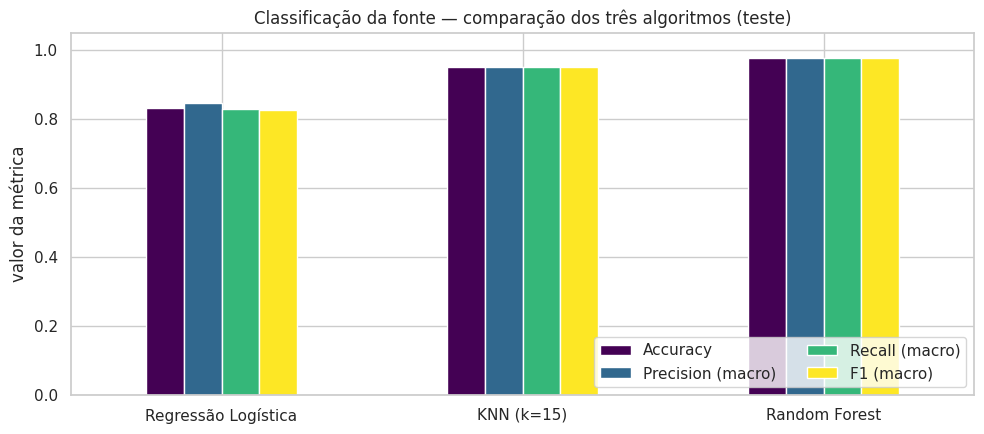

In [40]:
# Gráfico comparativo das métricas
tabela_cls[["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]].plot(
    kind="bar", figsize=(10, 4.5), rot=0, colormap="viridis")
plt.title("Classificação da fonte — comparação dos três algoritmos (teste)")
plt.ylabel("valor da métrica"); plt.ylim(0, 1.05); plt.xlabel("")
plt.legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

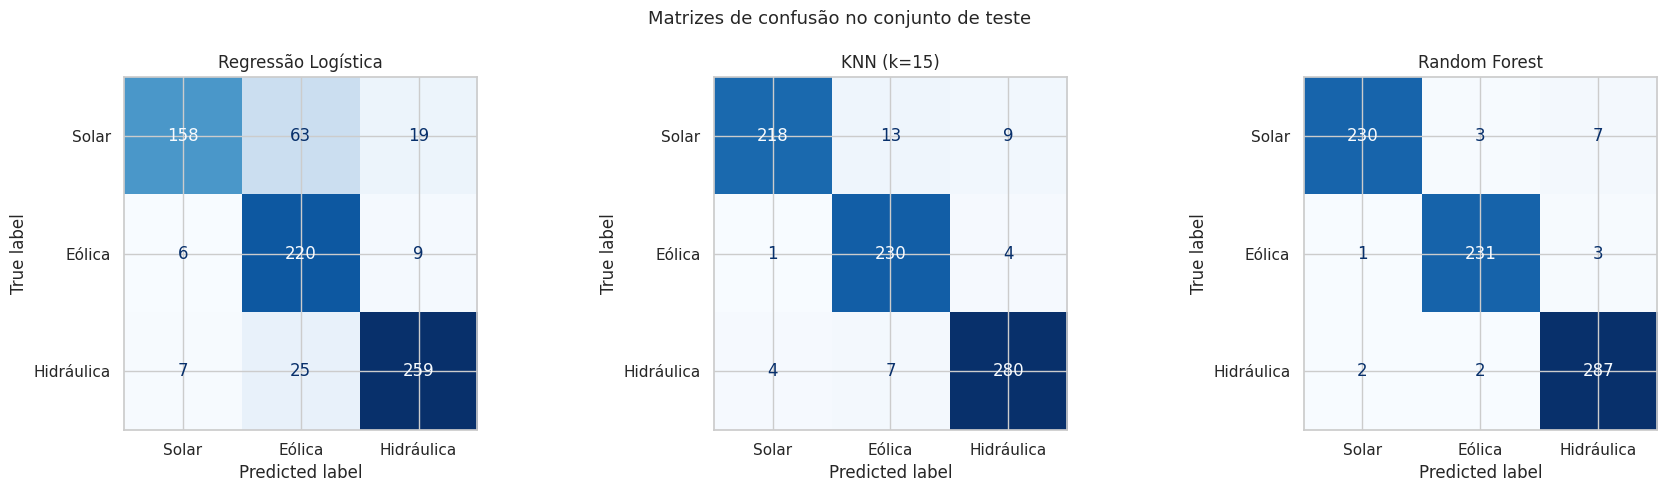

=== Regressão Logística ===
              precision    recall  f1-score   support

       Solar      0.924     0.658     0.769       240
      Eólica      0.714     0.936     0.810       235
  Hidráulica      0.902     0.890     0.896       291

    accuracy                          0.832       766
   macro avg      0.847     0.828     0.825       766
weighted avg      0.851     0.832     0.830       766

=== KNN (k=15) ===
              precision    recall  f1-score   support

       Solar      0.978     0.908     0.942       240
      Eólica      0.920     0.979     0.948       235
  Hidráulica      0.956     0.962     0.959       291

    accuracy                          0.950       766
   macro avg      0.951     0.950     0.950       766
weighted avg      0.952     0.950     0.950       766

=== Random Forest ===
              precision    recall  f1-score   support

       Solar      0.987     0.958     0.973       240
      Eólica      0.979     0.983     0.981       235
  Hidr

In [41]:
# Matrizes de confusão (linhas = classe real, colunas = classe prevista)
classes = ["Solar", "Eólica", "Hidráulica"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, previsao) in zip(axes, previsoes_cls.items()):
    ConfusionMatrixDisplay.from_predictions(yc_teste, previsao, labels=classes, ax=ax,
                                            cmap="Blues", colorbar=False)
    ax.set_title(nome)
plt.suptitle("Matrizes de confusão no conjunto de teste", fontsize=13)
plt.tight_layout(); plt.show()

# Desempenho por classe de cada modelo
for nome, previsao in previsoes_cls.items():
    print(f"=== {nome} ===")
    print(classification_report(yc_teste, previsao, labels=classes, digits=3, zero_division=0))

### 1.4 Teste de sensibilidade: o aglomerado de usinas solares de 1 kW

A análise exploratória mostrou que boa parte dos registros **Solar** da amostra tem potência de exatamente **1 kW** e está concentrada numa mesma região (latitude ≈ −2, longitude ≈ −52 a −53, no Pará). Um grupo tão homogêneo é muito fácil de reconhecer e pode inflar as métricas. Para medir esse efeito, recalculamos as métricas no **mesmo conjunto de teste, sem esses registros**. Os modelos não são retreinados.

In [42]:
solar_1kw = df_cls[(df_cls["fonte"] == "Solar") & (df_cls["potencia_kw"] == 1.0)]
print(f"Registros Solar com 1 kW: {len(solar_1kw)} de {(df_cls['fonte'] == 'Solar').sum()} solares")
print("Coordenadas medianas desse grupo:", solar_1kw[["latitude", "longitude"]].median().round(2).to_dict(), "\n")

fora_aglomerado = ~((yc_teste == "Solar") & (Xc_teste["potencia_kw"] == 1.0))
linhas = []
for nome, previsao in previsoes_cls.items():
    yt, yp = yc_teste[fora_aglomerado], previsao[fora_aglomerado.values]
    linhas.append({"Algoritmo": nome,
                   "Accuracy (teste completo)": tabela_cls.loc[nome, "Accuracy"],
                   "Accuracy (sem Solar 1 kW)": accuracy_score(yt, yp),
                   "F1 macro (teste completo)": tabela_cls.loc[nome, "F1 (macro)"],
                   "F1 macro (sem Solar 1 kW)": f1_score(yt, yp, average="macro"),
                   "Recall Solar (sem 1 kW)": recall_score(yt, yp, labels=["Solar"], average="macro")})
print(f"Registros de teste avaliados sem o aglomerado: {fora_aglomerado.sum()} de {len(yc_teste)}")
pd.DataFrame(linhas).set_index("Algoritmo")

Registros Solar com 1 kW: 752 de 1200 solares
Coordenadas medianas desse grupo: {'latitude': -1.97, 'longitude': -53.02} 

Registros de teste avaliados sem o aglomerado: 614 de 766


,Accuracy (teste completo),Accuracy (sem Solar 1 kW),F1 macro (teste completo),F1 macro (sem Solar 1 kW),Recall Solar (sem 1 kW)
Algoritmo,,,,,
Regressão Logística,0.8316,0.7899,0.8251,0.6062,0.0682
KNN (k=15),0.9504,0.9381,0.9497,0.9125,0.7500
Random Forest,0.9765,0.9707,0.9765,0.9601,0.8864


### Interpretação — Tarefa 1

**Comparação (teste com 766 registros, divisão estratificada 80/20, `random_state=42`, média `macro`):**

| Algoritmo | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---:|---:|---:|---:|
| Regressão Logística | 0,832 | 0,847 | 0,828 | 0,825 |
| KNN (k=15) | 0,950 | 0,951 | 0,950 | 0,950 |
| **Random Forest** | **0,977** | **0,977** | **0,976** | **0,977** |

Para comparação, chutar sempre a classe mais frequente acertaria apenas 38%. Os três modelos aprenderam padrões reais.

**Modelo escolhido: Random Forest.** Ele vence nas quatro métricas. A diferença para a Regressão Logística mostra que a fronteira entre as classes **não é linear**: as eólicas aparecem tanto no Nordeste quanto no extremo Sul, e uma única reta no plano latitude × longitude não consegue separar isso. O KNN e a Random Forest trabalham com regiões locais e se saem muito melhor.

**Classes mais confundidas: Solar ↔ Eólica.** Na Regressão Logística, 63 das 240 solares do teste foram classificadas como eólicas. Na Random Forest, 3 solares foram para Eólica e 7 para Hidráulica. O motivo é que as solares de grande porte e as eólicas têm **potência parecida** (em torno de 30 MW) e dividem o **mesmo território**, o interior do Nordeste. Com apenas três atributos, esses empreendimentos ficam praticamente indistinguíveis.

**O desempenho real é menor que o da tabela (seção 1.4).** Retirando do teste as solares de 1 kW do aglomerado do Pará, o F1 macro cai de 0,825 para 0,606 na Regressão Logística, de 0,950 para 0,913 no KNN e de 0,977 para 0,960 na Random Forest. O recall das demais solares é de apenas 6,8% na Regressão Logística, 75,0% no KNN e 88,6% na Random Forest. Parte do desempenho vem de um grupo fácil de reconhecer, criado pela forma de consulta.

**Limitações de prever a fonte só com potência e localização:**
1. **Os atributos são indiretos.** Nenhum deles mede a característica física da fonte (sol, vento ou água). O modelo aprende "onde costumam ficar" e "que tamanho costumam ter", e isso falha quando duas fontes se sobrepõem, como Solar e Eólica no Nordeste.
2. **A amostra não é representativa.** O limite de 1.200 registros por sigla e a ordem em que a API devolve os dados criam aglomerados artificiais, como as solares de 1 kW.
3. **Proximidade geográfica entre treino e teste.** Unidades vizinhas de um mesmo complexo, com potências iguais, podem cair uma no treino e outra no teste, o que facilita o acerto. Uma divisão por região (validação espacial) daria uma estimativa mais honesta.
4. **Mudanças no mercado.** A expansão solar em áreas antes dominadas por outras fontes altera os padrões, e o modelo teria de ser retreinado.

Numa aplicação real, a fonte já consta do cadastro. Um classificador assim só faria sentido para, por exemplo, validar registros inconsistentes, e mesmo nesse caso precisaria de atributos físicos como irradiação, velocidade média do vento e proximidade de rios.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [43]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [44]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [45]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [46]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## Resolução — Tarefa 2 (regressão da radiação solar)

### 2.1 Carregamento e análise exploratória

In [47]:
df_reg = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig")
df_reg["data_hora"] = pd.to_datetime(df_reg["data_hora"])
df_reg = df_reg.sort_values("data_hora").reset_index(drop=True)   # garante a ordem temporal

print("Linhas e colunas:", df_reg.shape)
print("Período:", df_reg["data_hora"].min(), "até", df_reg["data_hora"].max())
print("\nTipos das colunas:")
print(df_reg.dtypes)
print("\nValores ausentes por coluna:")
print(df_reg.isnull().sum())
display(df_reg.head())
display(df_reg.describe())

# Correlação de cada entrada com o alvo
entradas = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
print("\nCorrelação linear (Pearson) com radiacao_w_m2:")
print(df_reg[entradas + ["radiacao_w_m2"]].corr()["radiacao_w_m2"].drop("radiacao_w_m2").round(3))

Linhas e colunas: (1001, 7)
Período: 2025-04-01 07:00:00 até 2025-06-30 17:00:00

Tipos das colunas:
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3000,74,100,17.7000,7,116.0000
1,2025-04-01 08:00:00,26.5000,66,100,18.1000,8,269.0000
2,2025-04-01 09:00:00,28.4000,55,97,18.0000,9,529.0000
3,2025-04-01 10:00:00,30.8000,44,21,18.4000,10,797.0000
4,2025-04-01 11:00:00,32.7000,36,26,20.1000,11,880.0000


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,"1,001.0000","1,001.0000","1,001.0000","1,001.0000","1,001.0000","1,001.0000"
mean,2025-05-16 11:59:59.999999744,28.8859,50.5445,55.1089,15.4654,12.0000,472.8541
min,2025-04-01 07:00:00,19.5000,21.0000,0.0000,2.3000,7.0000,13.0000
25%,2025-04-23 15:00:00,26.3000,38.0000,19.0000,12.2000,9.0000,250.0000
50%,2025-05-16 12:00:00,29.1000,49.0000,54.0000,15.4000,12.0000,466.0000
75%,2025-06-08 09:00:00,31.7000,61.0000,98.0000,19.0000,15.0000,696.0000
max,2025-06-30 17:00:00,36.1000,95.0000,100.0000,30.1000,17.0000,"1,002.0000"
std,NaN,3.6565,15.9140,37.8515,4.9236,3.1639,256.3690



Correlação linear (Pearson) com radiacao_w_m2:
temperatura_c    0.6430
umidade_pct     -0.5960
nuvens_pct      -0.1800
vento_kmh       -0.2290
hora             0.1200
Name: radiacao_w_m2, dtype: float64


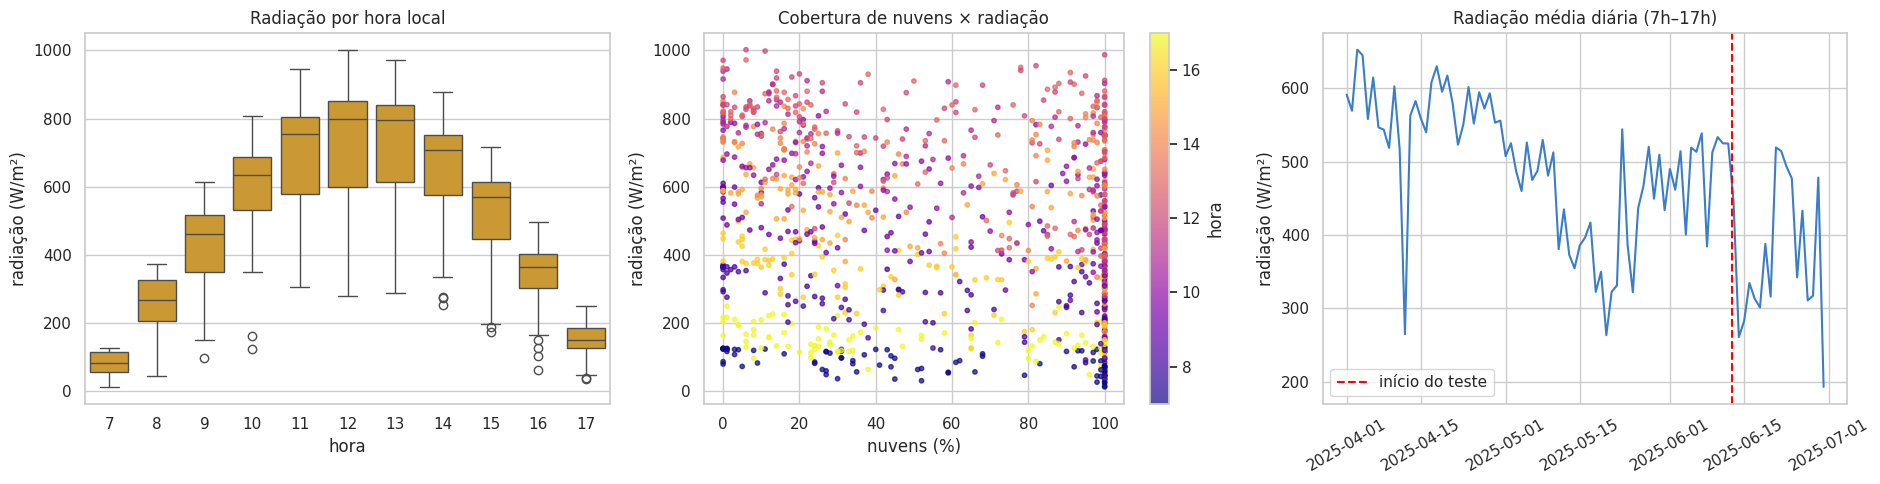

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# (a) Radiação por hora do dia: formato de "sino"
sns.boxplot(data=df_reg, x="hora", y="radiacao_w_m2", color="#E3A21A", ax=axes[0])
axes[0].set_title("Radiação por hora local")
axes[0].set_ylabel("radiação (W/m²)")

# (b) Relação entre nuvens e radiação, colorida pela hora
sc = axes[1].scatter(df_reg["nuvens_pct"], df_reg["radiacao_w_m2"], c=df_reg["hora"],
                     cmap="plasma", s=10, alpha=0.7)
fig.colorbar(sc, ax=axes[1], label="hora")
axes[1].set_title("Cobertura de nuvens × radiação")
axes[1].set_xlabel("nuvens (%)"); axes[1].set_ylabel("radiação (W/m²)")

# (c) Média diária ao longo do período, marcando onde começa o teste
diaria = df_reg.set_index("data_hora")["radiacao_w_m2"].resample("D").mean()
axes[2].plot(diaria.index, diaria.values, color="#3A7DC9")
inicio_teste = df_reg["data_hora"].iloc[int(len(df_reg) * 0.8)]
axes[2].axvline(inicio_teste, color="red", ls="--", label="início do teste")
axes[2].set_title("Radiação média diária (7h–17h)")
axes[2].set_ylabel("radiação (W/m²)"); axes[2].legend()
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

### Registro da análise exploratória — Tarefa 2

- **Tamanho e qualidade:** são 1.001 horas (91 dias × 11 horas, das 7h às 17h), de 01/04/2025 07h a 30/06/2025 17h, **sem valores ausentes**. A radiação varia de 13 a 1.002 W/m², com média de 473 W/m².
- **Hora do dia:** a radiação tem formato de **sino**. Sobe de ≈ 90 W/m² às 7h até ≈ 800 W/m² ao meio-dia e volta a cair até ≈ 150 W/m² às 17h. A correlação linear entre `hora` e radiação é só **0,12**, e **isso não significa que a hora seja pouco importante**: a relação sobe e depois desce, e a correlação de Pearson só mede relações do tipo "quanto mais, mais".
- **Temperatura (r = 0,64) e umidade (r = −0,60):** são as correlações mais fortes, mas em boa parte porque acompanham o próprio ciclo do sol. O sol aquece o ar e reduz a umidade relativa. Elas funcionam em parte como **reflexo** da radiação, não como causa.
- **Nuvens (r = −0,18):** a relação é mais fraca do que se esperaria. Cerca de 21% das horas têm 100% de cobertura e, mesmo assim, algumas registram radiação alta. A variável `cloud_cover` da reanálise soma todas as camadas de nuvens, inclusive nuvens altas e finas que deixam passar boa parte do sol. Em média, a radiação cai de ≈ 585 W/m² (nuvens ≤ 10%) para ≈ 386 W/m² (nuvens ≥ 95%).
- **Tendência sazonal:** a média diária cai de ≈ 600 W/m² no início de abril para 300–500 W/m² em junho, com a aproximação do solstício de inverno (sol mais baixo). Por isso o **período de teste** (12/06 a 30/06) tem radiação média menor (373 W/m²) que o de treino (498 W/m²). O modelo é avaliado num regime um pouco diferente do que aprendeu, o que é justamente o desafio de uma avaliação temporal honesta.

### 2.2 Definição de `X` e `y` e divisão temporal

- **`X` (entradas):** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`.
- **`y` (alvo):** `radiacao_w_m2`.
- `data_hora` serve apenas para ordenar e separar os dados; **não entra em `X`**. A radiação também não entra em `X`, nem transformada.

A divisão é **temporal**: as primeiras 80% das horas vão para o treino e as 20% finais para o teste, sem embaralhar. Esse é o cenário realista, em que o modelo aprende com o passado e é avaliado no futuro. Com uma divisão aleatória, horas vizinhas (muito parecidas entre si) cairiam uma no treino e outra no teste, e o resultado ficaria otimista demais.

In [49]:
X_reg = df_reg[entradas]
y_reg = df_reg["radiacao_w_m2"]

corte = int(len(df_reg) * 0.8)            # índice onde termina o treino
Xr_treino, Xr_teste = X_reg.iloc[:corte], X_reg.iloc[corte:]
yr_treino, yr_teste = y_reg.iloc[:corte], y_reg.iloc[corte:]

print(f"Treino: {len(Xr_treino)} horas | {df_reg['data_hora'].iloc[0]} → {df_reg['data_hora'].iloc[corte - 1]}")
print(f"Teste : {len(Xr_teste)} horas | {df_reg['data_hora'].iloc[corte]} → {df_reg['data_hora'].iloc[-1]}")
assert df_reg["data_hora"].iloc[:corte].max() < df_reg["data_hora"].iloc[corte:].min()  # nenhum "futuro" no treino

Treino: 800 horas | 2025-04-01 07:00:00 → 2025-06-12 14:00:00
Teste : 201 horas | 2025-06-12 15:00:00 → 2025-06-30 17:00:00


### 2.3 Escolha dos três regressores

| Algoritmo | Por que foi escolhido |
|---|---|
| **Regressão Linear** | Linha de base. Supõe que cada entrada soma ou subtrai radiação de forma proporcional. Mostra quanto do problema é linear. |
| **KNN Regressor (k=10)** | Estima a radiação pela média das 10 horas mais parecidas do treino (mesma hora, nuvens e temperatura semelhantes). Capta relações não lineares. Precisa de padronização, porque usa distâncias. |
| **Random Forest Regressor** | Média de várias árvores de decisão. Capta não linearidades (o "sino" da hora) e interações (o efeito das nuvens depende da hora) sem precisar de padronização. |

Como antes, a padronização fica dentro de um `Pipeline`, ajustada somente com o treino.

In [50]:
regressores = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "KNN (k=10)": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10)),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                           random_state=SEMENTE, n_jobs=-1),
}

resultados_reg, previsoes_reg = [], {}
for nome, modelo in regressores.items():
    modelo.fit(Xr_treino, yr_treino)
    previsao = modelo.predict(Xr_teste)
    previsoes_reg[nome] = previsao
    mse = mean_squared_error(yr_teste, previsao)
    resultados_reg.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mean_absolute_error(yr_teste, previsao),
        "MSE ((W/m²)²)": mse,
        "RMSE (W/m²)": np.sqrt(mse),     # erro na mesma unidade do alvo (MSE = RMSE²)
        "R²": r2_score(yr_teste, previsao),
    })

tabela_reg = pd.DataFrame(resultados_reg).set_index("Algoritmo")
print("Configuração: divisão temporal 80/20 (primeiras horas = treino), mesma divisão para os três modelos\n")
tabela_reg

Configuração: divisão temporal 80/20 (primeiras horas = treino), mesma divisão para os três modelos



,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Algoritmo,,,,
Regressão Linear,145.2049,"30,034.2011",173.3038,0.3598
KNN (k=10),72.1766,"8,222.9276",90.6804,0.8247
Random Forest,67.1898,"7,419.5985",86.1371,0.8419


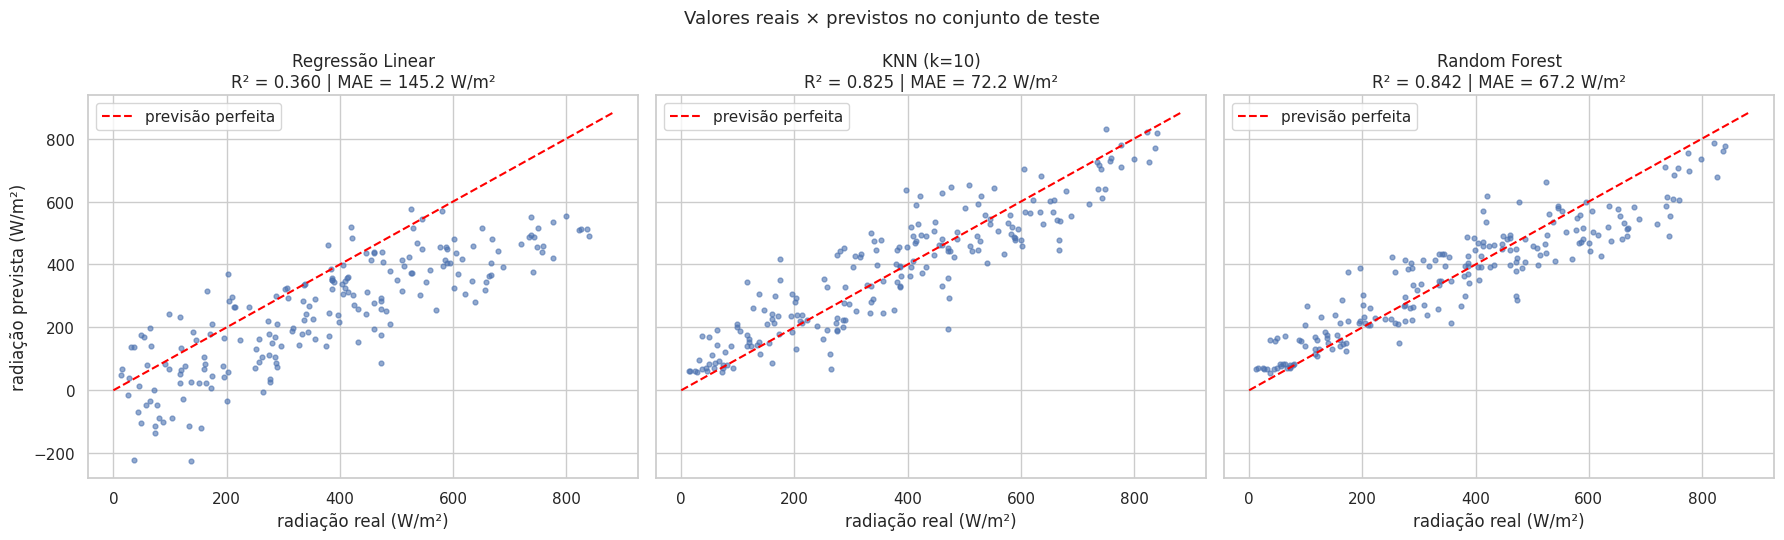

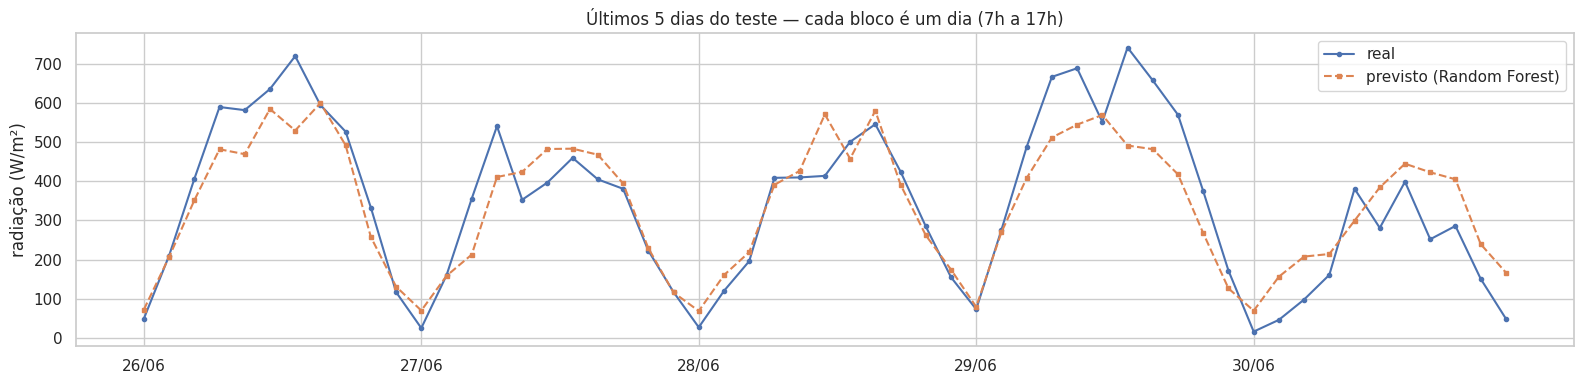

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)
limite = [0, max(yr_teste.max(), max(p.max() for p in previsoes_reg.values())) * 1.05]
for ax, (nome, previsao) in zip(axes, previsoes_reg.items()):
    ax.scatter(yr_teste, previsao, s=12, alpha=0.6)
    ax.plot(limite, limite, color="red", ls="--", label="previsão perfeita")
    ax.set_title(f"{nome}\nR² = {tabela_reg.loc[nome, 'R²']:.3f} | MAE = {tabela_reg.loc[nome, 'MAE (W/m²)']:.1f} W/m²")
    ax.set_xlabel("radiação real (W/m²)")
    ax.legend(loc="upper left")
axes[0].set_ylabel("radiação prevista (W/m²)")
plt.suptitle("Valores reais × previstos no conjunto de teste", fontsize=13)
plt.tight_layout(); plt.show()

# Série temporal dos últimos 5 dias do teste: real × melhor modelo
melhor_reg = tabela_reg["R²"].idxmax()
ultimos = df_reg.iloc[corte:].tail(55)   # 5 dias × 11 horas
plt.figure(figsize=(16, 4))
plt.plot(range(len(ultimos)), ultimos["radiacao_w_m2"].values, "o-", label="real", ms=3)
plt.plot(range(len(ultimos)), previsoes_reg[melhor_reg][-55:], "s--", label=f"previsto ({melhor_reg})", ms=3)
plt.xticks(range(0, len(ultimos), 11), ultimos["data_hora"].dt.strftime("%d/%m").iloc[::11])
plt.ylabel("radiação (W/m²)")
plt.title("Últimos 5 dias do teste — cada bloco é um dia (7h a 17h)")
plt.legend(); plt.tight_layout(); plt.show()

### 2.4 O papel da hora do dia

Dois testes para medir o peso da hora:
1. **Importância por permutação** no teste: embaralha uma entrada por vez e mede quanto o R² cai. Quanto maior a queda, mais o modelo depende daquela variável.
2. **Retreinar os modelos sem `hora`** e comparar as métricas.

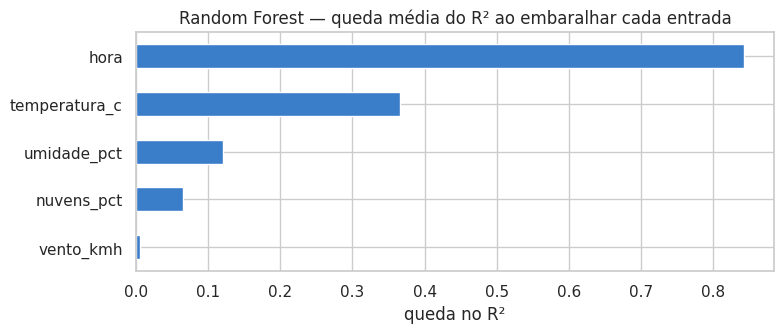

,R² com hora,R² sem hora,MAE com hora,MAE sem hora
Algoritmo,,,,
Regressão Linear,0.3598,0.3074,145.2049,145.6943
KNN (k=10),0.8247,0.3543,72.1766,131.0443
Random Forest,0.8419,0.3408,67.1898,130.8215


In [52]:
rf = regressores["Random Forest"]
perm = permutation_importance(rf, Xr_teste, yr_teste, n_repeats=20, random_state=SEMENTE, scoring="r2")
importancia = pd.Series(perm.importances_mean, index=entradas).sort_values()

importancia.plot(kind="barh", figsize=(8, 3.5), color="#3A7DC9")
plt.title("Random Forest — queda média do R² ao embaralhar cada entrada")
plt.xlabel("queda no R²"); plt.tight_layout(); plt.show()

# Mesmos três algoritmos, agora SEM a coluna hora
entradas_sem_hora = [c for c in entradas if c != "hora"]
linhas = []
for nome, modelo in regressores.items():
    m = clone(modelo).fit(Xr_treino[entradas_sem_hora], yr_treino)
    p = m.predict(Xr_teste[entradas_sem_hora])
    linhas.append({"Algoritmo": nome,
                   "R² com hora": tabela_reg.loc[nome, "R²"], "R² sem hora": r2_score(yr_teste, p),
                   "MAE com hora": tabela_reg.loc[nome, "MAE (W/m²)"], "MAE sem hora": mean_absolute_error(yr_teste, p)})
pd.DataFrame(linhas).set_index("Algoritmo")

**Resultado — papel da hora:**

- Embaralhar a coluna `hora` derruba o R² da Random Forest em **≈ 0,84**, bem mais do que qualquer outra entrada (temperatura ≈ 0,37; umidade ≈ 0,12; nuvens ≈ 0,06; vento ≈ 0).
- Retreinando **sem a hora**, o R² da Random Forest cai de 0,842 para 0,341, e o MAE quase dobra (de 67 para 131 W/m²). O KNN cai de 0,825 para 0,354.

**Por que a hora pesa tanto:** ela determina a **altura do sol no céu** e, portanto, o **teto** de radiação possível naquele momento. As condições do tempo (nuvens, umidade) apenas reduzem esse teto. Sem a hora, o modelo não sabe se 60% de nuvens às 8h significa 150 W/m² ou se ao meio-dia significa 600 W/m².

**Por que a Regressão Linear quase não muda sem a hora** (R² de 0,360 para 0,307): uma reta não representa um sino. O melhor que ela consegue é uma inclinação média, então a informação da hora fica praticamente inaproveitada. É isso que explica o desempenho ruim da Regressão Linear. Uma forma de corrigir seria transformar a hora antes, por exemplo com `sin(π·(hora − 6)/12)`, que imita a curva do sol, ou com uma variável binária para cada hora.

### Interpretação — Tarefa 2

**Comparação (teste: 201 horas finais, de 12/06 15h a 30/06 17h; mesma divisão temporal para os três):**

| Algoritmo | MAE (W/m²) | MSE ((W/m²)²) | R² |
|---|---:|---:|---:|
| Regressão Linear | 145,2 | 30.034 | 0,360 |
| KNN (k=10) | 72,2 | 8.223 | 0,825 |
| **Random Forest** | **67,2** | **7.420** | **0,842** |

**Modelo escolhido: Random Forest.** Tem o menor MAE, o menor MSE e o maior R². O KNN fica próximo, porque também capta o formato de sino da hora. A Regressão Linear erra o dobro em média e chega a prever **radiação negativa** em 19 das 201 horas, um valor fisicamente impossível que mostra o limite de um modelo linear para esse problema.

**Análise dos erros (Random Forest):**
- O RMSE de 86 W/m² corresponde a cerca de 23% da radiação média do período de teste (373 W/m²). A estimativa é útil, mas não é precisa hora a hora.
- O erro médio com sinal é de −9 W/m², ou seja, quase não há viés sistemático.
- Os erros absolutos são maiores entre 10h e 15h (≈ 75–95 W/m²) e menores às 7h e às 17h (≈ 20–45 W/m²). Perto do meio-dia os valores são maiores e a passagem de nuvens altera mais a radiação.
- No gráfico real × previsto, a Random Forest **subestima os picos** dos dias limpos e **superestima** as horas muito nubladas. As previsões ficam "puxadas para o meio", comportamento típico de modelos que fazem médias, como árvores e vizinhos.
- Parte do erro vem da mudança sazonal: o teste (fim de junho) tem radiação menor que o treino (abril a início de junho).

### Por que estimar a radiação não equivale a prever a geração elétrica

O modelo estima a **radiação global horizontal**, a potência da luz solar que chega a cada m² de uma superfície **horizontal**, em W/m². A energia elétrica que um sistema fotovoltaico entrega depende de muitos outros fatores:

1. **Unidade e tempo:** W/m² é uma densidade de potência, não energia. Para chegar a kWh é preciso multiplicar pela **área dos painéis** e **integrar ao longo do tempo**.
2. **Eficiência dos módulos:** os painéis comerciais convertem só cerca de 18% a 23% da radiação em eletricidade.
3. **Inclinação e orientação:** os painéis normalmente ficam inclinados e voltados para uma direção. A radiação no plano do painel é diferente da horizontal.
4. **Temperatura das células:** o calor **reduz** a eficiência. Em Petrolina, as horas mais ensolaradas também são as mais quentes, então mais radiação não significa geração proporcionalmente maior.
5. **Perdas do sistema:** inversor, cabos, sujeira, sombreamento, degradação dos módulos, cortes de geração pelo operador da rede e indisponibilidades.
6. **Origem dos dados:** os valores vêm de modelos de reanálise, não de um sensor no local nem de um painel real.

Além disso, o modelo usa as condições do tempo **da mesma hora** para estimar a radiação. Ele **não faz previsão do futuro**: para prever a radiação de amanhã, seria preciso uma previsão meteorológica de amanhã como entrada.

Estimar a radiação é, portanto, o **primeiro passo** para estimar a geração, e não a geração em si.

## Conclusões gerais

| Tarefa | Configuração de avaliação | Melhor modelo | Resultado |
|---|---|---|---|
| 1 — Classificação da fonte (ANEEL) | Estratificada 80/20, `random_state=42`, métricas `macro` | Random Forest | Accuracy 0,977 · F1 macro 0,977 |
| 2 — Regressão da radiação (Open-Meteo) | Temporal: 80% primeiras horas × 20% finais | Random Forest | MAE 67,2 W/m² · MSE 7.420 · R² 0,842 |

- Nas duas tarefas, os modelos **não lineares** (Random Forest e KNN) superaram com folga os lineares (Regressão Logística e Regressão Linear). Os padrões de localização das fontes e o ciclo diário do sol não seguem uma reta.
- Na classificação, o resultado precisa ser lido com cautela: parte do acerto vem de um aglomerado de solares de 1 kW criado pela forma de consulta. Sem ele, o F1 macro da Random Forest cai para 0,960, e a Regressão Logística praticamente deixa de reconhecer as demais solares.
- Na regressão, a **hora do dia** é a variável mais importante: sem ela, o R² cai de 0,84 para 0,34. Estimar a radiação é só o primeiro passo para estimar a geração fotovoltaica.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)